# Testing the FOLDE Module Machinery

This notebook tests the functionality of the FOLDE (Few-shot and zerO-shot Learning for protein Design and Engineering) module, particularly focusing on the data loading functionality.

In [3]:
%load_ext autoreload
%autoreload 2
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Configure logging
import logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(name)s - %(levelname)s - %(message)s')
logger = logging.getLogger()

from folde.data import get_available_proteingym_datasets, get_proteingym_dataset
from folde.campaign import simulate_campaign, simulate_campaigns
from folde.types import FolDEModelConfig, ModelEvaluation

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Importing the FOLDE Module

First, let's try to import our FOLDE module functions.

# Import the FOLDE module
try:
    from folde import get_available_proteingym_datasets, get_proteingym_dataset
    print("Successfully imported the FOLDE module functions!")
except Exception as e:
    print(f"Error importing the FOLDE module: {e}")

In [4]:
# Define paths
from folde.data import MODULE_DIR, DATA_DIR, DMS_DIR, EMBEDDINGS_DIR, NATURALNESS_DIR, DMS_METADATA_FILE

print(f"Module directory: {MODULE_DIR}")
print(f"Data directory: {DATA_DIR}")
print(f"DMS directory: {DMS_DIR}")
print(f"Embeddings directory: {EMBEDDINGS_DIR}")
print(f"Naturalness directory: {NATURALNESS_DIR}")
print(f"DMS metadata file: {DMS_METADATA_FILE}")

Module directory: /Users/jacobroberts/git/foldy/backend/src/folde
Data directory: /Users/jacobroberts/git/foldy/backend/src/folde/data
DMS directory: /Users/jacobroberts/git/foldy/backend/src/folde/data/DMS_ProteinGym_substitutions
Embeddings directory: /Users/jacobroberts/git/foldy/backend/src/folde/data/embeddings
Naturalness directory: /Users/jacobroberts/git/foldy/backend/src/folde/data/naturalness
DMS metadata file: /Users/jacobroberts/git/foldy/backend/src/folde/data/DMS_substitutions.csv


## Testing get_available_proteingym_datasets

Now let's test the `get_available_proteingym_datasets` function with specific embedding and naturalness models.

In [5]:

embedding_model_id = '300m'
naturalness_model_id = '600m'

print(f"Testing with embedding model: {embedding_model_id} and naturalness model: {naturalness_model_id}")
available_datasets = get_available_proteingym_datasets(embedding_model_id, naturalness_model_id)

if not available_datasets.empty:
    print(f"Found {len(available_datasets)} available datasets")
    print("\nSample of available datasets:")
    display(available_datasets.head(20))
else:
    print("No datasets found with these models")

2025-03-23 12:37:04,455 - folde.data - INFO - Loaded metadata for 217 DMS datasets
2025-03-23 12:37:04,468 - folde.data - INFO - Found 9 datasets with embedding model '300m' and naturalness model '600m'


Testing with embedding model: 300m and naturalness model: 600m
Found 9 available datasets

Sample of available datasets:


,DMS_id,DMS_filename,UniProt_ID,taxon,source_organism,target_seq,seq_len,includes_multiple_mutants,DMS_total_number_mutants,DMS_number_single_mutants,...,raw_DMS_filename,raw_DMS_phenotype_name,raw_DMS_directionality,raw_DMS_mutant_column,weight_file_name,pdb_file,pdb_range,ProteinGym_version,raw_mut_offset,coarse_selection_type
0,A0A140D2T1_ZIKV_Sourisseau_2019,A0A140D2T1_ZIKV_Sourisseau_2019.csv,A0A140D2T1_ZIKV,Virus,Zika virus (ZIKV),MKNPKKKSGGFRIVNMLKRGVARVNPLGGLKRLPAGLLLGHGPIRM...,3423,False,9576,9576,...,A0A140D2T1_ZIKV_Sourisseau_growth_2019.csv,effect,1,mutant,A0A140D2T1_ZIKV_theta_0.01.npy,A0A140D2T1_ZIKV.pdb,291-794,0.1,NaN,OrganismalFitness
4,A0A2Z5U3Z0_9INFA_Doud_2016,A0A2Z5U3Z0_9INFA_Doud_2016.csv,A0A2Z5U3Z0_9INFA,Virus,Influenza A virus (A/WSN/1933(H1N1)),MKAKLLVLLYAFVATDADTICIGYHANNSTDTVDTILEKNVAVTHS...,565,False,10715,10715,...,A0A2Z5U3Z0_9INFA_Doud_2016.csv,transformed_pref,1,mutant,A0A2Z5U3Z0_9INFA_theta_0.01.npy,A0A2Z5U3Z0_9INFA.pdb,1-565,0.1,NaN,OrganismalFitness
11,ADRB2_HUMAN_Jones_2020,ADRB2_HUMAN_Jones_2020.csv,ADRB2_HUMAN,Human,Homo sapiens,MGQPGNGSAFLLAPNGSHAPDHDVTQERDEVWVVGMGIVMSLIVLA...,413,False,7800,7800,...,ADRB2_HUMAN_Jones_2020.csv,0.625,1,mutant_id,ADRB2_HUMAN_theta_0.2.npy,ADRB2_HUMAN.pdb,1-413,0.1,NaN,Activity
23,BLAT_ECOLX_Stiffler_2015,BLAT_ECOLX_Stiffler_2015.csv,BLAT_ECOLX,Prokaryote,Escherichia coli,MSIQHFRVALIPFFAAFCLPVFAHPETLVKVKDAEDQLGARVGYIE...,286,False,4996,4996,...,BLAT_ECOLX_Stiffler_2015.csv,2500,1,mutant,BLAT_ECOLX_theta_0.2.npy,BLAT_ECOLX.pdb,1-286,0.1,NaN,OrganismalFitness
26,C6KNH7_9INFA_Lee_2018,C6KNH7_9INFA_Lee_2018.csv,C6KNH7_9INFA,Virus,Influenza A virus (A/Perth/16/2009(H3N2)),MKTIIALSYILCLVFAQKLPGNDNSTATLCLGHHAVPNGTIVKTIT...,566,False,10754,10754,...,C6KNH7_9INFA_Lee_2018.csv,log_fitness_by_syn_mut_fitness,1,mutant,C6KNH7_9INFA_theta_0.01.npy,C6KNH7_9INFA.pdb,1-566,0.1,NaN,OrganismalFitness
81,IF1_ECOLI_Kelsic_2016,IF1_ECOLI_Kelsic_2016.csv,IF1_ECOLI,Prokaryote,Escherichia coli,MAKEDNIEMQGTVLETLPNTMFRVELENGHVVTAHISGKMRKNYIR...,72,False,1367,1367,...,IF1_ECOLI_Kelsic_2016.csv,fitness_rich,1,mutant,IF1_ECOLI_theta_0.2.npy,IF1_ECOLI.pdb,1-72,0.1,NaN,OrganismalFitness
95,MK01_HUMAN_Brenan_2016,MK01_HUMAN_Brenan_2016.csv,MK01_HUMAN,Human,Homo sapiens,MAAAAAAGAGPEMVRGQVFDVGPRYTNLSYIGEGAYGMVCSAYDNV...,360,False,6809,6809,...,MK01_HUMAN_Brenan_2016.csv,DOX_Average,-1,mutant,MK01_HUMAN_theta_0.2.npy,MK01_HUMAN.pdb,1-360,0.1,NaN,OrganismalFitness
116,P53_HUMAN_Giacomelli_2018_Null_Etoposide,P53_HUMAN_Giacomelli_2018_Null_Etoposide.csv,P53_HUMAN,Human,Homo sapiens,MEEPQSDPSVEPPLSQETFSDLWKLLPENNVLSPLPSQAMDDLMLS...,393,False,7467,7467,...,P53_HUMAN_Giacomelli_2018.csv,A549_p53NULL_Etoposide_Z-score,1,Allele,P53_HUMAN_theta_0.2.npy,P53_HUMAN.pdb,1-393,0.1,NaN,OrganismalFitness
124,PHOT_CHLRE_Chen_2023,PHOT_CHLRE_Chen_2023.csv,PHOT_CHLRE,Eukaryote,Chlamydomonas reinhardtii,AGLRHTFVVADATLPDCPLVYASEGFYAMTGYGPDEVLGHNARFLQ...,118,True,167529,2122,...,sb2c00662_si_001.xlsx,mean,1,mutant,PHOT_CHLRE_theta0.2_2023-08-07_b02.npy,PHOT_CHLRE.pdb,1-118,1.0,NaN,Activity


In [6]:
dms_id = available_datasets['DMS_id'].iloc[0]
    
print(f"Testing with dataset: {dms_id}, embedding model: {embedding_model_id}, naturalness model: {naturalness_model_id}")

try:
    naturalness_df, embedding_df, activity_df = get_proteingym_dataset(dms_id, embedding_model_id, naturalness_model_id)
    print(f"Successfully loaded datasets:")
    print(f"  - Naturalness data: {len(naturalness_df)} rows")
    print(f"  - Embedding data: {len(embedding_df)} rows")
    print(f"  - Activity data: {len(activity_df)} rows")
    
    # Display dataset summaries
    print("\nNaturalness DataFrame columns:")
    print(naturalness_df.columns.tolist())
    
    print("\nEmbedding DataFrame columns:")
    print(embedding_df.columns.tolist())
    
    print("\nActivity DataFrame columns:")
    print(activity_df.columns.tolist())
    
    # Display sample of each dataframe
    print("\nSample of naturalness data:")
    display(naturalness_df.head())
    
    print("\nSample of activity data:")
    display(activity_df.head())
    
    # Check embedding format
    print("\nEmbedding format:")
    embedding = embedding_df['embedding'].iloc[0]
    print(f"Type: {type(embedding)}")
    print(f"Shape: {embedding.shape if hasattr(embedding, 'shape') else 'N/A'}")
    print(f"First 5 values: {embedding[:5] if hasattr(embedding, '__getitem__') else 'N/A'}")
    
    # Check seq_id format in all dataframes
    print("\nSeq_id examples:")
    print(f"Naturalness first seq_id: {naturalness_df['seq_id'].iloc[0] if 'seq_id' in naturalness_df.columns else 'N/A'}")
    print(f"Embedding first seq_id: {embedding_df['seq_id'].iloc[0] if 'seq_id' in embedding_df.columns else 'N/A'}")
    print(f"Activity first seq_id: {activity_df['seq_id'].iloc[0] if 'seq_id' in activity_df.columns else 'N/A'}")
    
except Exception as e:
    print(f"Error loading dataset: {e}")
    raise e

Testing with dataset: A0A140D2T1_ZIKV_Sourisseau_2019, embedding model: 300m, naturalness model: 600m


2025-03-23 12:37:04,916 - folde.data - INFO - Loaded activity data for A0A140D2T1_ZIKV_Sourisseau_2019 with 9576 rows
2025-03-23 12:37:06,452 - folde.data - INFO - Loaded embeddings for A0A140D2T1_ZIKV_Sourisseau_2019 with 9577 rows
2025-03-23 12:37:06,475 - folde.data - INFO - Loaded naturalness scores for A0A140D2T1_ZIKV_Sourisseau_2019 with 16632 rows


Successfully loaded datasets:
  - Naturalness data: 9576 rows
  - Embedding data: 9576 rows
  - Activity data: 9576 rows

Naturalness DataFrame columns:
['seq_id', 'probability', 'locus', 'wt_probability', 'wt_marginal']

Embedding DataFrame columns:
['seq_id', 'seq', 'embedding']

Activity DataFrame columns:
['mutant', 'mutated_sequence', 'DMS_score', 'DMS_score_bin', 'seq_id']

Sample of naturalness data:


,seq_id,probability,locus,wt_probability,wt_marginal
seq_id,,,,,
W764D,W764D,0.003540,474,0.038086,0.092949
G682A,G682A,0.051758,392,0.298828,0.173203
I442P,I442P,0.029785,152,0.091797,0.324468
E467F,E467F,0.040283,177,0.058594,0.687500
V763C,V763C,0.044189,473,0.224609,0.196739



Sample of activity data:


,mutant,mutated_sequence,DMS_score,DMS_score_bin,seq_id
seq_id,,,,,
W764D,W764D,MKNPKKKSGGFRIVNMLKRGVARVNPLGGLKRLPAGLLLGHGPIRM...,0.042673,0,W764D
G682A,G682A,MKNPKKKSGGFRIVNMLKRGVARVNPLGGLKRLPAGLLLGHGPIRM...,0.978660,1,G682A
I442P,I442P,MKNPKKKSGGFRIVNMLKRGVARVNPLGGLKRLPAGLLLGHGPIRM...,0.103520,1,I442P
E467F,E467F,MKNPKKKSGGFRIVNMLKRGVARVNPLGGLKRLPAGLLLGHGPIRM...,0.031142,0,E467F
V763C,V763C,MKNPKKKSGGFRIVNMLKRGVARVNPLGGLKRLPAGLLLGHGPIRM...,0.150037,1,V763C



Embedding format:
Type: <class 'numpy.ndarray'>
Shape: (960,)
First 5 values: [-0.00142757 -0.00427054  0.00361812  0.00376403  0.00746457]

Seq_id examples:
Naturalness first seq_id: W764D
Embedding first seq_id: W764D
Activity first seq_id: W764D


# Test out a simulation campaign

In [10]:
import numpy as np

# Example configuration
config_list = [
  FolDEModelConfig(
    name='Random',
    naturalness_model_id="600m",
    embedding_model_id="300m",
    zero_shot_model_name="RandomZeroShotModel",
    zero_shot_model_params={},
    few_shot_model_name="RandomFewShotModel",
    few_shot_model_params={}
  ),
    FolDEModelConfig(
        name="Random->RandomForest",
        # Required parameters
        naturalness_model_id="600m",  # ESM-2 650M model
        embedding_model_id="300m",  # Same model for embeddings
        zero_shot_model_name="RandomZeroShotModel",
        zero_shot_model_params={},
        # Few-shot model configuration (used after first round)
        few_shot_model_name="RandomForestFewShotModel",
        few_shot_model_params={
            "n_estimators": 100,
            "criterion": "friedman_mse",
            "max_depth": None,
            "min_samples_split": 2,
            "min_samples_leaf": 1,
            "min_weight_fraction_leaf": 0.0,
            "max_features": 1.0,
            "max_leaf_nodes": None,
            "min_impurity_decrease": 0.0,
            "bootstrap": True,
            "oob_score": False,
            "n_jobs": None,
            "random_state": 1,
            "verbose": 0,
            "warm_start": False,
            "ccp_alpha": 0.0,
            "max_samples": None,
        },
    ),
    FolDEModelConfig(
        name="WTMarginalT2->RandomForest",
        # Required parameters
        naturalness_model_id="600m",  # ESM-2 650M model
        embedding_model_id="300m",  # Same model for embeddings
        zero_shot_model_name="NaturalnessZeroShotModel",
        zero_shot_model_params={
          "temperature": 2.0,
        },
        # Few-shot model configuration (used after first round)
        few_shot_model_name="RandomForestFewShotModel",
        few_shot_model_params={
            "n_estimators": 100,
            "criterion": "friedman_mse",
            "max_depth": None,
            "min_samples_split": 2,
            "min_samples_leaf": 1,
            "min_weight_fraction_leaf": 0.0,
            "max_features": 1.0,
            "max_leaf_nodes": None,
            "min_impurity_decrease": 0.0,
            "bootstrap": True,
            "oob_score": False,
            "n_jobs": None,
            "random_state": 1,
            "verbose": 0,
            "warm_start": False,
            "ccp_alpha": 0.0,
            "max_samples": None,
        },
    ),
    FolDEModelConfig(
        name="WTMarginalT1->RandomForest",
        # Required parameters
        naturalness_model_id="600m",  # ESM-2 650M model
        embedding_model_id="300m",  # Same model for embeddings
        zero_shot_model_name="NaturalnessZeroShotModel",
        zero_shot_model_params={
          "temperature": 1.0,
        },
        # Few-shot model configuration (used after first round)
        few_shot_model_name="RandomForestFewShotModel",
        few_shot_model_params={
            "n_estimators": 100,
            "criterion": "friedman_mse",
            "max_depth": None,
            "min_samples_split": 2,
            "min_samples_leaf": 1,
            "min_weight_fraction_leaf": 0.0,
            "max_features": 1.0,
            "max_leaf_nodes": None,
            "min_impurity_decrease": 0.0,
            "bootstrap": True,
            "oob_score": False,
            "n_jobs": None,
            "random_state": 1,
            "verbose": 0,
            "warm_start": False,
            "ccp_alpha": 0.0,
            "max_samples": None,
        },
    ),
    FolDEModelConfig(
        name="WTMarginalT05->RandomForest",
        # Required parameters
        naturalness_model_id="600m",  # ESM-2 650M model
        embedding_model_id="300m",  # Same model for embeddings
        zero_shot_model_name="NaturalnessZeroShotModel",
        zero_shot_model_params={
          "temperature": 0.5,
        },
        # Few-shot model configuration (used after first round)
        few_shot_model_name="RandomForestFewShotModel",
        few_shot_model_params={
            "n_estimators": 100,
            "criterion": "friedman_mse",
            "max_depth": None,
            "min_samples_split": 2,
            "min_samples_leaf": 1,
            "min_weight_fraction_leaf": 0.0,
            "max_features": 1.0,
            "max_leaf_nodes": None,
            "min_impurity_decrease": 0.0,
            "bootstrap": True,
            "oob_score": False,
            "n_jobs": None,
            "random_state": 1,
            "verbose": 0,
            "warm_start": False,
            "ccp_alpha": 0.0,
            "max_samples": None,
        },
    ),
    FolDEModelConfig(
        name="WTMarginal->RandomForest",
        # Required parameters
        naturalness_model_id="600m",  # ESM-2 650M model
        embedding_model_id="300m",  # Same model for embeddings
        zero_shot_model_name="NaturalnessZeroShotModel",
        zero_shot_model_params={},
        # Few-shot model configuration (used after first round)
        few_shot_model_name="RandomForestFewShotModel",
        few_shot_model_params={
            "n_estimators": 100,
            "criterion": "friedman_mse",
            "max_depth": None,
            "min_samples_split": 2,
            "min_samples_leaf": 1,
            "min_weight_fraction_leaf": 0.0,
            "max_features": 1.0,
            "max_leaf_nodes": None,
            "min_impurity_decrease": 0.0,
            "bootstrap": True,
            "oob_score": False,
            "n_jobs": None,
            "random_state": 1,
            "verbose": 0,
            "warm_start": False,
            "ccp_alpha": 0.0,
            "max_samples": None,
        },
    ),
    # Another configuration to compare
    FolDEModelConfig(
        name="Random->MLP",
        naturalness_model_id="600m",
        embedding_model_id="300m",
        zero_shot_model_name="NaturalnessZeroShotModel",
        zero_shot_model_params={},
        few_shot_model_name="MLPFewShotModel",
        few_shot_model_params={
            "random_state": 1,
            "max_iter": 5000,
            "hidden_layer_sizes": (100, 50),
        },
    ),
    # Another configuration to compare
    FolDEModelConfig(
        name="WTMarginalT2->MLP",
        naturalness_model_id="600m",
        embedding_model_id="300m",
        zero_shot_model_name="NaturalnessZeroShotModel",
        zero_shot_model_params={
          "temperature": 2.0,
        },
        few_shot_model_name="MLPFewShotModel",
        few_shot_model_params={
            "random_state": 1,
            "max_iter": 5000,
            "hidden_layer_sizes": (100, 50),
        },
    ),
    # Another configuration to compare
    FolDEModelConfig(
        name="WTMarginal->MLP",
        naturalness_model_id="600m",
        embedding_model_id="300m",
        zero_shot_model_name="NaturalnessZeroShotModel",
        zero_shot_model_params={},
        few_shot_model_name="MLPFewShotModel",
        few_shot_model_params={
            "random_state": 1,
            "max_iter": 5000,
            "hidden_layer_sizes": (100, 50),
        },
    ),
    # Another configuration to compare
    FolDEModelConfig(
        name="WTMarginal->MLP (n_iter100)",
        naturalness_model_id="600m",
        embedding_model_id="300m",
        zero_shot_model_name="NaturalnessZeroShotModel",
        zero_shot_model_params={},
        few_shot_model_name="MLPFewShotModel",
        few_shot_model_params={
            "random_state": 1,
            "max_iter": 5000,
            "hidden_layer_sizes": (100, 50),
            "n_iter_no_change": 100,
        },
    ),
]

# Run the simulation=
results = simulate_campaigns(
  name='zero_shot_with_boltzmann',
  dms_ids=available_datasets['DMS_id'].values[:1],
  round_size=16,
  number_of_simulations=10,
  config_list=config_list[:2],
  activity_column="DMS_score",
  max_rounds=6,
  random_seed=42,
)

2025-03-23 12:38:14,314 - folde.campaign - INFO - Running simulations for configuration 1/2
2025-03-23 12:38:14,315 - folde.campaign - INFO - Config: name='Random' naturalness_model_id='600m' embedding_model_id='300m' zero_shot_model_name='RandomZeroShotModel' zero_shot_model_params={} few_shot_model_name='RandomFewShotModel' few_shot_model_params={}
2025-03-23 12:38:14,600 - folde.data - INFO - Loaded activity data for A0A140D2T1_ZIKV_Sourisseau_2019 with 9576 rows
2025-03-23 12:38:16,116 - folde.data - INFO - Loaded embeddings for A0A140D2T1_ZIKV_Sourisseau_2019 with 9577 rows
2025-03-23 12:38:16,136 - folde.data - INFO - Loaded naturalness scores for A0A140D2T1_ZIKV_Sourisseau_2019 with 16632 rows
2025-03-23 12:38:22,348 - folde.campaign - INFO - Running simulations for configuration 2/2
2025-03-23 12:38:22,349 - folde.campaign - INFO - Config: name='Random->RandomForest' naturalness_model_id='600m' embedding_model_id='300m' zero_shot_model_name='RandomZeroShotModel' zero_shot_model

In [12]:
import json
with open(f'notebooks/jacob/model_evals/{results.name}.json', 'w') as f:
  json.dump(results.model_dump(), f, indent=2)

# TODO: Fix plotting code...

In [14]:
from folde.util import convert_compaign_result_collection_to_df
mutant_df, round_metrics_df = convert_compaign_result_collection_to_df(results)

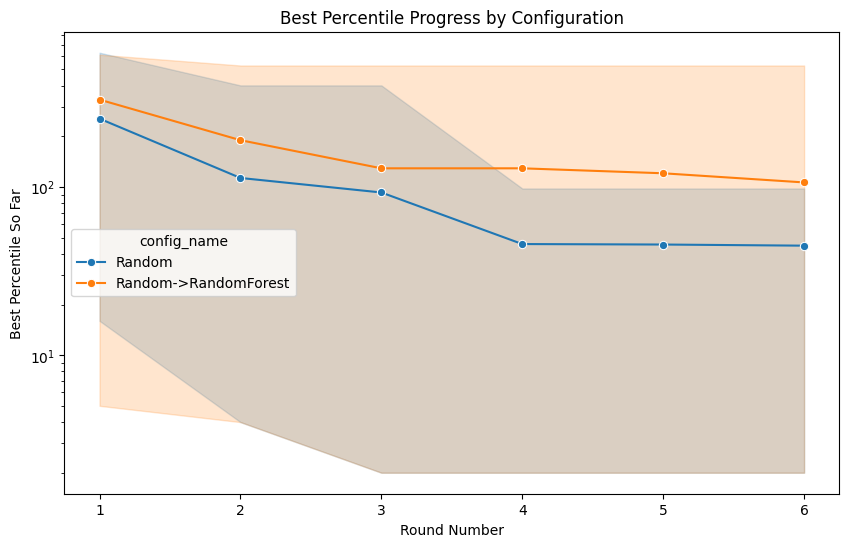

In [15]:
import seaborn as sns

plot_df = round_metrics_df.copy()
plot_df['distance_to_top'] = plot_df.apply(lambda r: int((1.0 - r['best_percentile_so_far']) * r['variant_pool_size']), axis=1)

# Create the line plot
plt.figure(figsize=(10, 6))
sns.lineplot(
  data=plot_df, 
  x='round_num', 
  y='distance_to_top',
  hue='config_name',
  # Show aggregated.
  marker='o',
  errorbar=('pi', 100),  # This shows min to max range (0th to 100th percentile)

  # Show individually.
  # markers=True,
  # units='sim_num',
  # estimator=None,
  # ci=None,
)

# Customize the plot
plt.title('Best Percentile Progress by Configuration')
plt.xlabel('Round Number')
plt.ylabel('Best Percentile So Far')
plt.yscale('log')

# plt.ylim(0.95, 1.0)


/var/folders/p6/jn7zk09154v2f60d993vb2sm0000gn/T/ipykernel_84452/108425597.py:28: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(data=df, x=x_column, y=y_column, hue=hue_column,
/var/folders/p6/jn7zk09154v2f60d993vb2sm0000gn/T/ipykernel_84452/108425597.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/var/folders/p6/jn7zk09154v2f60d993vb2sm0000gn/T/ipykernel_84452/108425597.py:28: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(data=df, x=x_column, y=y_column, hue=hue_column,
/var/folders/p6/jn7zk09154v2f60d993vb2sm0000gn/T/ipykernel_84452/108425597.py:32: UserWarning: set_ticklabels() should only 

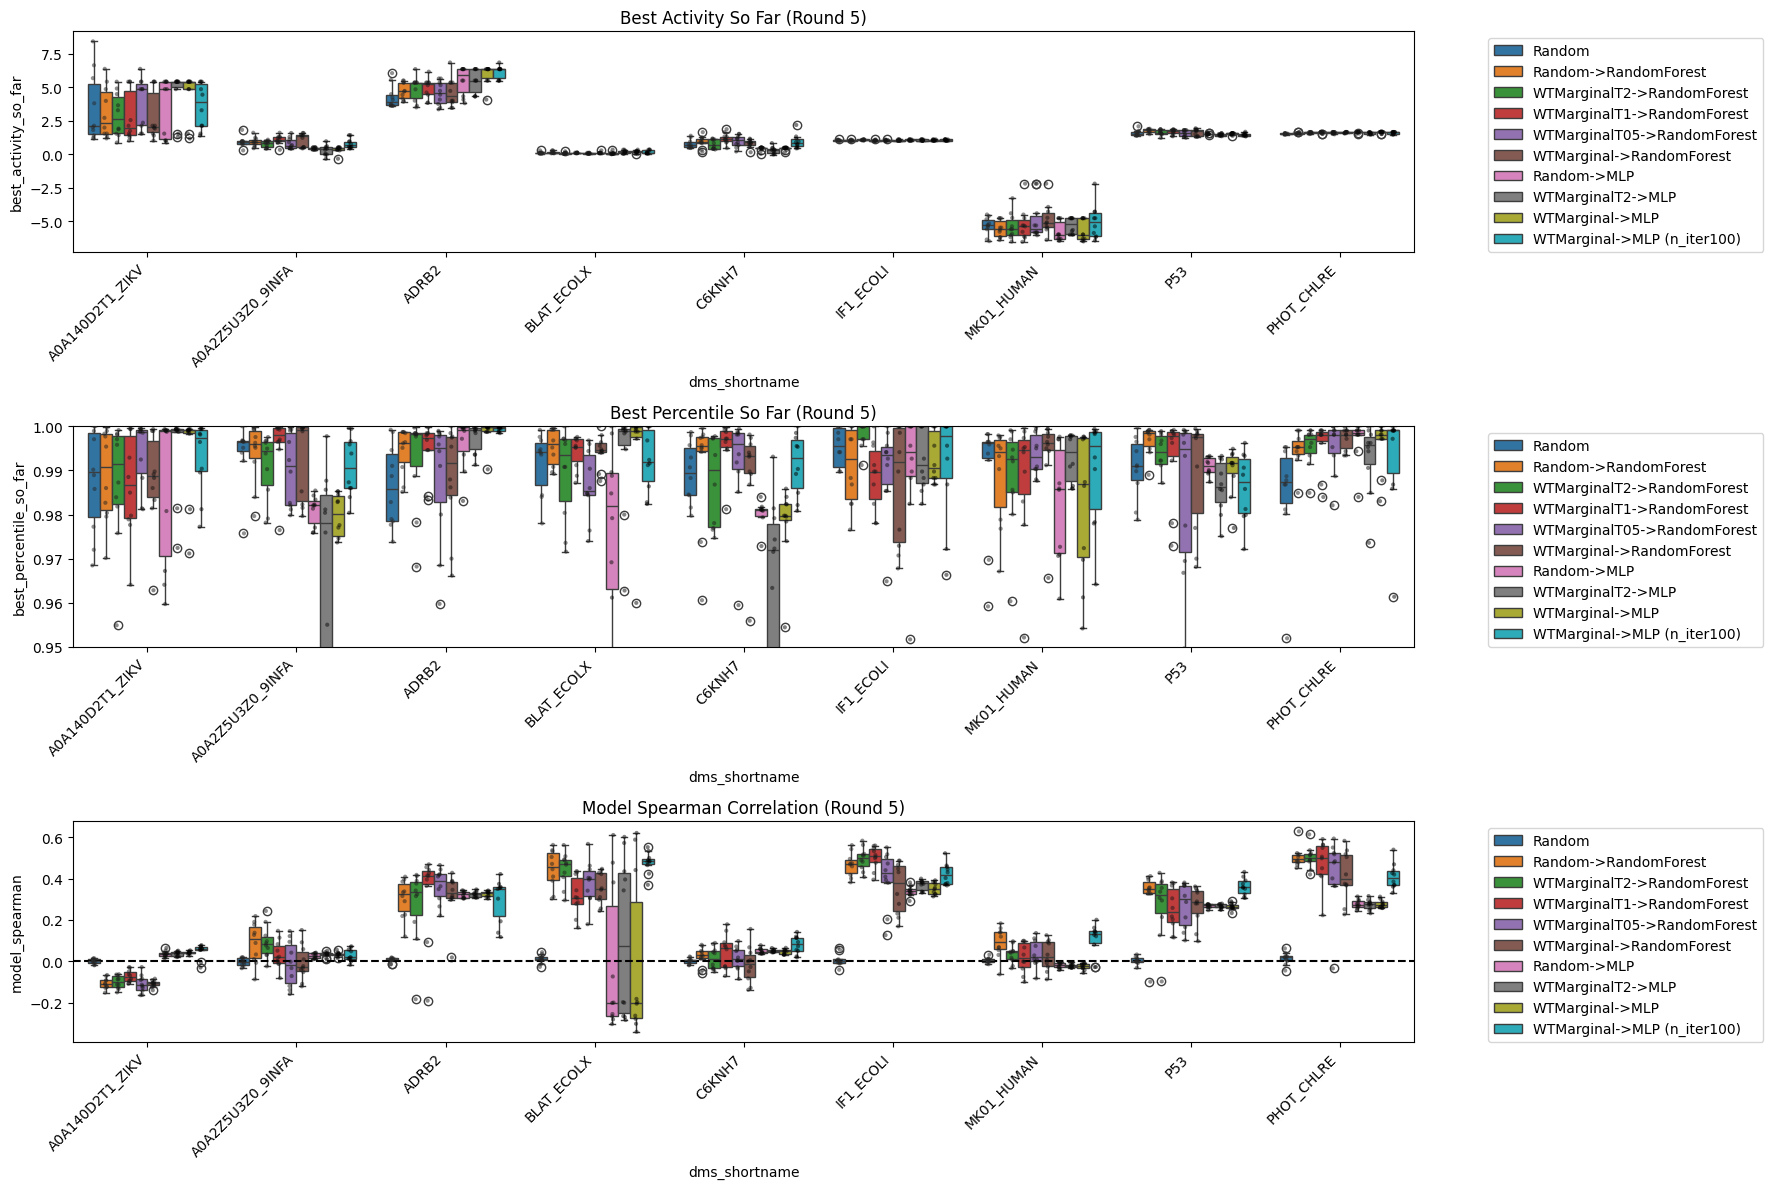

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

DMS_SHORTNAMES = {
  'A0A140D2T1_ZIKV_Sourisseau_2019': "A0A140D2T1_ZIKV",
  'A0A2Z5U3Z0_9INFA_Doud_2016': "A0A2Z5U3Z0_9INFA",
  'ADRB2_HUMAN_Jones_2020': "ADRB2",
  'BLAT_ECOLX_Stiffler_2015': "BLAT_ECOLX",
  'C6KNH7_9INFA_Lee_2018': "C6KNH7",
  'IF1_ECOLI_Kelsic_2016': "IF1_ECOLI",
  'MK01_HUMAN_Brenan_2016': "MK01_HUMAN",
  'P53_HUMAN_Giacomelli_2018_Null_Etoposide': "P53",
  'PHOT_CHLRE_Chen_2023': "PHOT_CHLRE",
}

ROUND = 5

single_round_df = round_metrics_df[round_metrics_df.round_num == ROUND].copy()
single_round_df['dms_shortname'] = single_round_df.dms_id.apply(lambda x: DMS_SHORTNAMES.get(x))
single_round_df['config_name'] = single_round_df.config_name.apply(lambda x: 'EvolvePro (ESMC300M)' if x == 'EvolvePro' else x)


def plot_metric_panel(ax, df, y_column, x_column='dms_shortname', hue_column='config_name'):
    # Create boxplot
    sns.boxplot(data=df, x=x_column, y=y_column, hue=hue_column, ax=ax)
    
    # Overlay stripplot with black dots
    sns.stripplot(data=df, x=x_column, y=y_column, hue=hue_column,
                 dodge=True, alpha=0.5, ax=ax, size=3, color='black', legend=False)
    
    # Style the plot
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Set up the figure with three subplots
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(18, 12), height_ratios=[1, 1, 1])
fig.tight_layout(pad=3.0)

# Top panel: best_activity_so_far
plot_metric_panel(ax1, single_round_df, 'best_activity_so_far')
ax1.set_title(f'Best Activity So Far (Round {ROUND})')

# Middle panel: best_percentile_so_far
plot_metric_panel(ax2, single_round_df, 'best_percentile_so_far')
ax2.set_title(f'Best Percentile So Far (Round {ROUND})')
ax2.set_ylim(0.95, 1.0)

# Bottom panel: model_spearman
plot_metric_panel(ax3, single_round_df, 'model_spearman')
ax3.set_title(f'Model Spearman Correlation (Round {ROUND})')
ax3.axhline(0.0, linestyle='--', color='k')

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()


In [9]:
mutant_df

,config_name,sim_number,seq_id,round_found,activity,predicted_activity,percentile,relevant_mutants
0,EvolvePro,0,T107K,1,-2.826024,0.999461,0.118895,[]
1,EvolvePro,0,D212V,1,-1.849025,0.999350,0.369095,[]
2,EvolvePro,0,E164I,1,-2.868440,0.998793,0.106886,[]
3,EvolvePro,0,W163A,1,-0.356232,0.997749,0.602882,[]
4,EvolvePro,0,P181Y,1,-3.051126,0.997672,0.050040,[]
...,...,...,...,...,...,...,...,...
1275,MLP n_iter_no_change100,4,E56I,4,-2.184077,0.082474,0.281025,[]
1276,MLP n_iter_no_change100,4,D113C,4,-0.304002,0.074341,0.609287,[]
1277,MLP n_iter_no_change100,4,D269R,4,-0.115254,0.072125,0.696958,[]
1278,MLP n_iter_no_change100,4,E277I,4,-0.017570,0.068915,0.863090,[]


2025-03-17 12:19:38,789 - matplotlib.category - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-03-17 12:19:38,794 - matplotlib.category - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
/Users/jacobroberts/miniforge3/envs/esm_jupyter/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 9.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/jacobroberts/miniforge3/envs/esm_jupyter/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 11.9% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarn

<Axes: xlabel='round_idx', ylabel='percentile'>

/Users/jacobroberts/miniforge3/envs/esm_jupyter/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 10.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/Users/jacobroberts/miniforge3/envs/esm_jupyter/lib/python3.12/site-packages/seaborn/categorical.py:3399: UserWarning: 14.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


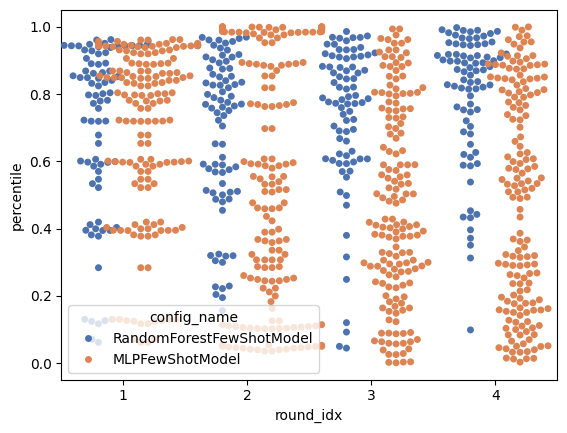

In [13]:
import seaborn as sns

activities_list = []
for config_idx, config_results in enumerate(results.simulation_results):
  config = config_results[0]
  sim_results = config_results[1]

  # config_name = config.zeroshot_model_name + ' → ' + config.fewshot_model_name
  config_name = config.fewshot_model_name

  for sim_idx, sim_result in enumerate(sim_results):
    for round_idx, tested_variant_percentiles in enumerate(sim_result.tested_variant_percentiles):
      for percentile in tested_variant_percentiles:
        activities_list.append({
          'config_name': config_name,
          'sim_idx': sim_idx,
          'round_idx': round_idx + 1,
          'percentile': percentile
        })

activities_df = pd.DataFrame(activities_list)

sns.swarmplot(data=activities_df, x="round_idx", y="percentile", hue="config_name", palette="deep", dodge=True)


/var/folders/p6/jn7zk09154v2f60d993vb2sm0000gn/T/ipykernel_2575/3846258015.py:56: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(
/var/folders/p6/jn7zk09154v2f60d993vb2sm0000gn/T/ipykernel_2575/3846258015.py:72: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(
/var/folders/p6/jn7zk09154v2f60d993vb2sm0000gn/T/ipykernel_2575/3846258015.py:88: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(


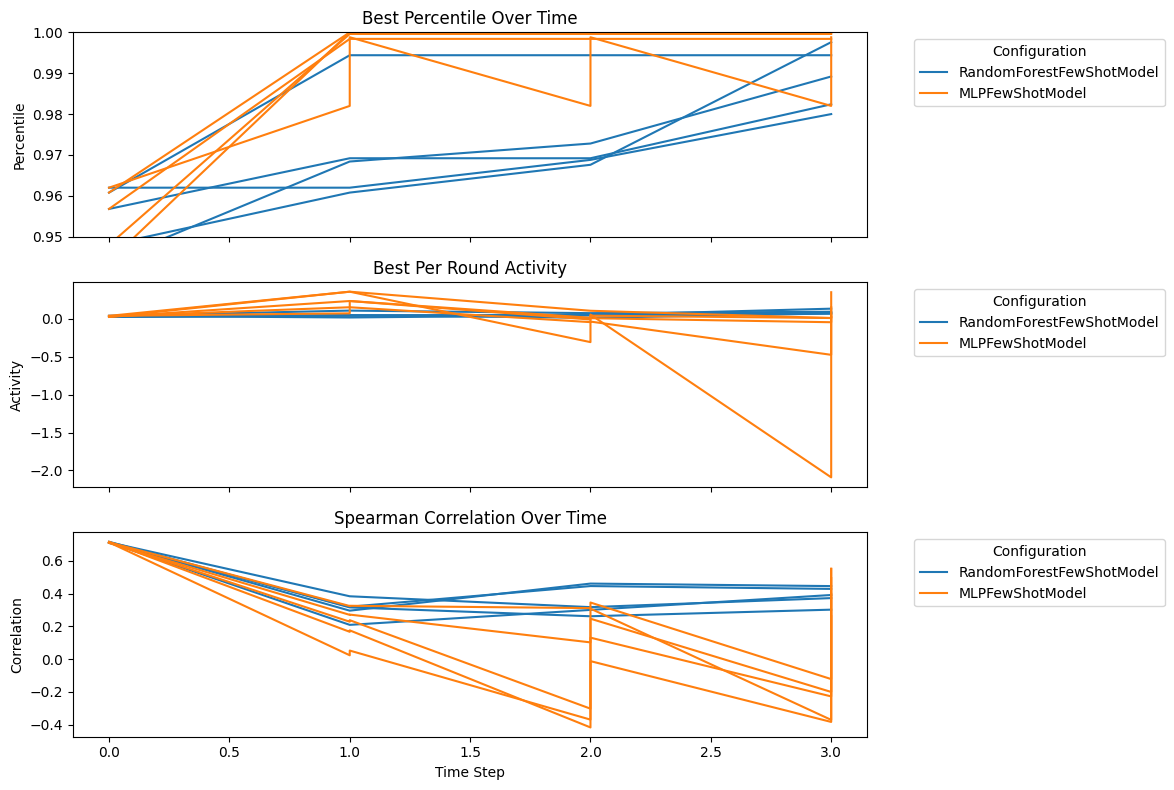

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# First, let's reshape your data into a format suitable for seaborn
data_list = []

# Assuming results['simulation_results'] is your data structure
for config_idx, (model_config, sim_results) in enumerate(results.simulation_results):
    # config_name = results['configurations'][config_idx]['config']['zeroshot_model_name'] + ' → ' + results['configurations'][config_idx]['config']['fewshot_model_name']
    config_name = model_config.few_shot_model_name
    for sim_idx, sim in enumerate(sim_results):
        # Get both metrics for this simulation
        cumulative_best_percentile_list = sim.cumulative_best_percentile
        best_activity_per_round_list = sim.best_activity_per_round
        round_metrics_list = sim.round_metrics
        
        # Add cumulative best percentile data
        for t, activity in enumerate(cumulative_best_percentile_list):
            data_list.append({
                'Time': t,
                'Value': activity,
                'Metric': 'Best Percentile',
                'Config': config_name,  
                'Simulation': sim_idx
            })

        # Add cumulative best percentile data
        for t, activity in enumerate(best_activity_per_round_list):
            data_list.append({
                'Time': t,
                'Value': activity,
                'Metric': 'Best Activity Per Round',
                'Config': config_name,
                'Simulation': sim_idx
            })
        
        # Add Spearman correlation data
        for t, round_metrics in enumerate(round_metrics_list):
            data_list.append({
                'Time': t,
                'Value': round_metrics['whole_dataset_spearman'],
                'Metric': 'Spearman Correlation',
                'Config': config_name,
                'Simulation': sim_idx
            })

# Convert to DataFrame
df_plot = pd.DataFrame(data_list)

# Create figure with subplots
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

# Plot Best Percentile
sns.lineplot(
    data=df_plot[df_plot['Metric'] == 'Best Percentile'],
    x='Time',
    y='Value',
    hue='Config',
    units='Simulation',
    estimator=None,
    ci=None,
    ax=ax1
)
ax1.set_ylim(0.95, 1.0)
ax1.set_title('Best Percentile Over Time')
ax1.set_ylabel('Percentile')
ax1.legend(title='Configuration', bbox_to_anchor=(1.05, 1))

# Plot Best Percentile
sns.lineplot(
    data=df_plot[df_plot['Metric'] == 'Best Activity Per Round'],
    x='Time',
    y='Value',
    hue='Config',
    # ci=95,
    units='Simulation',
    estimator=None,
    ci=None,
    ax=ax2
)
ax2.set_title('Best Per Round Activity')
ax2.set_ylabel('Activity')
ax2.legend(title='Configuration', bbox_to_anchor=(1.05, 1))

# Plot Spearman Correlation
sns.lineplot(
    data=df_plot[df_plot['Metric'] == 'Spearman Correlation'],
    x='Time',
    y='Value',
    hue='Config',
    units='Simulation',
    estimator=None,
    ci=None,
    ax=ax3
)
ax3.set_title('Spearman Correlation Over Time')
ax3.set_xlabel('Time Step')
ax3.set_ylabel('Correlation')
ax3.legend(title='Configuration', bbox_to_anchor=(1.05, 1))

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

In [3]:
df_plot

NameError: name 'df_plot' is not defined

In [42]:
df_plot

,Time,Activity,Config,Simulation
0,0,NaN,Config 0,0
1,1,NaN,Config 0,0
2,2,NaN,Config 0,0
3,3,NaN,Config 0,0
4,4,NaN,Config 0,0
5,0,NaN,Config 0,1
6,1,NaN,Config 0,1
7,2,NaN,Config 0,1
8,3,NaN,Config 0,1
9,4,NaN,Config 0,1


In [28]:
results['simulation_results'][1]

[{'config': {'naturalness_model_id': '600m',
   'embedding_model_id': '300m',
   'zeroshot_model_name': 'NaturalnessZeroShotModel',
   'zeroshot_model_params': {'distance_metric': 'euclidean'},
   'fewshot_model_name': 'MLPFewShotModel',
   'fewshot_model_params': {'random_state': 1,
    'max_iter': 5000,
    'hidden_layer_sizes': (100, 50)}},
  'rounds': [1, 2, 3, 4, 5],
  'best_variant_per_round': ['S122E', 'K32H', 'R273E', 'G76L', 'H94R'],
  'best_activity_per_round': [0.036991756,
   0.006558769,
   -0.007542683,
   -1.685606461,
   -0.03804817],
  'cumulative_best_activity': [0.036991756,
   0.036991756,
   0.036991756,
   0.036991756,
   0.036991756],
  'tested_variants': [['M180T',
    'M180S',
    'M153I',
    'H151R',
    'M153L',
    'Y44V',
    'Y44A',
    'L199P',
    'F58Y',
    'L196A',
    'N173G',
    'F228W',
    'S264T',
    'P25A',
    'S122E',
    'L196V'],
   ['R81D',
    'L282D',
    'R255Y',
    'G85H',
    'R91Y',
    'G39H',
    'L120D',
    'R273T',
    'R273M

In [16]:
metrics

{'mean_best_activity': 0.154985174,
 'std_best_activity': 0.0,
 'mean_percentile_rank': 99.85988791032825,
 'std_percentile_rank': 0.0,
 'mean_improvement_over_wt': 0.0,
 'std_improvement_over_wt': 0.0,
 'num_simulations': 5}

# If we have datasets, visualize aspects of them
if 'naturalness_df' in locals() and 'embedding_df' in locals() and 'activity_df' in locals():
    # Plot 1: Embedding dimensionality
    plt.figure(figsize=(14, 5))
    plt.subplot(1, 2, 1)
    embedding = embedding_df['embedding'].iloc[0]
    plt.hist(embedding, bins=30, alpha=0.7)
    plt.title(f'Histogram of First Embedding Values\n(dimension={len(embedding) if hasattr(embedding, "__len__") else "unknown"})')
    plt.xlabel('Value')
    plt.ylabel('Frequency')
    
    # Plot 2: Naturalness distribution
    if 'naturalness' in naturalness_df.columns:
        plt.subplot(1, 2, 2)
        plt.hist(naturalness_df['naturalness'], bins=30, alpha=0.7)
        plt.title('Distribution of Naturalness Scores')
        plt.xlabel('Naturalness')
        plt.ylabel('Frequency')
    
    plt.tight_layout()
    plt.show()
    
    # If there is a clear target column for fitness or activity, visualize it
    possible_target_cols = ['fitness', 'score', 'activity', 'DMS_score', 'measurement']
    target_col = None
    
    for col in possible_target_cols:
        if col in activity_df.columns and activity_df[col].dtype in [np.float64, np.int64]:
            target_col = col
            break
    
    if target_col:
        plt.figure(figsize=(14, 5))
        
        # Plot target distribution
        plt.subplot(1, 2, 1)
        plt.hist(activity_df[target_col], bins=30, alpha=0.7)
        plt.title(f'Distribution of {target_col}')
        plt.xlabel(target_col)
        plt.ylabel('Frequency')
        
        # Checking if we can match naturalness data with activity data
        if 'seq_id' in activity_df.columns and 'seq_id' in naturalness_df.columns:
            # Merge datasets for plotting
            merged = activity_df[['seq_id', target_col]].merge(
                naturalness_df[['seq_id', 'naturalness']], on='seq_id', how='inner'
            )
            
            if not merged.empty:
                plt.subplot(1, 2, 2)
                plt.scatter(merged['naturalness'], merged[target_col], alpha=0.5)
                plt.title(f'Naturalness vs {target_col}')
                plt.xlabel('Naturalness')
                plt.ylabel(target_col)
                print(f"Merged {len(merged)} rows with both naturalness and {target_col} data")
            else:
                print("Could not merge naturalness with activity data - no matching seq_ids")
        
        plt.tight_layout()
        plt.show()
else:
    print("No datasets available for visualization")

In [ ]:
# If we have available datasets, test loading one
if 'available_datasets' in locals() and not available_datasets.empty:
    # Use the first available dataset for testing
    dms_id = available_datasets['DMS_id'].iloc[0]
    
    print(f"Testing with dataset: {dms_id}, embedding model: {embedding_model_id}, naturalness model: {naturalness_model_id}")
    
    try:
        dataset = get_proteingym_dataset(dms_id, embedding_model_id, naturalness_model_id)
        print(f"Successfully loaded dataset with {len(dataset)} rows")
        
        # Display dataset summary
        print("\nDataset columns:")
        print(dataset.columns.tolist())
        
        print("\nSample of dataset (first 5 rows, selected columns):")
        display_cols = [col for col in dataset.columns if col not in ['embedding']]
        display(dataset[display_cols].head())
        
        # Check embedding format
        print("\nEmbedding format:")
        embedding = dataset['embedding'].iloc[0]
        print(f"Type: {type(embedding)}")
        print(f"Shape: {embedding.shape}")
        print(f"First 5 values: {embedding[:5]}")
        
        # Check naturalness format
        if 'naturalness' in dataset.columns:
            print("\nNaturalness format:")
            print(f"Type: {type(dataset['naturalness'].iloc[0])}")
            print(f"Range: {dataset['naturalness'].min()} to {dataset['naturalness'].max()}")
            print(f"Mean: {dataset['naturalness'].mean():.4f}")
    except Exception as e:
      raise e
else:
    print("No available datasets to test loading")

Testing with dataset: A0A140D2T1_ZIKV_Sourisseau_2019, embedding model: 300m, naturalness model: 650m


2025-03-15 13:46:03,907 - prediction.data - INFO - Loaded DMS data for A0A140D2T1_ZIKV_Sourisseau_2019 with 9576 rows
2025-03-15 13:46:05,472 - prediction.data - INFO - Loaded embeddings for A0A140D2T1_ZIKV_Sourisseau_2019 with 9577 rows
2025-03-15 13:46:05,482 - prediction.data - INFO - Loaded naturalness scores for A0A140D2T1_ZIKV_Sourisseau_2019 with 13608 rows


KeyError: 'seq_id'

## Visualizing Data

If we successfully loaded a dataset, let's visualize some aspects of it.

In [ ]:
# If we have a dataset, visualize it
if 'dataset' in locals() and not dataset.empty:
    plt.figure(figsize=(14, 5))
    
    # Plot 1: Embedding dimensionality
    plt.subplot(1, 2, 1)
    embedding = dataset['embedding'].iloc[0]
    plt.hist(embedding, bins=30, alpha=0.7)
    plt.title(f'Histogram of First Embedding Values\n(dimension={len(embedding)})')
    plt.xlabel('Value')
    plt.ylabel('Frequency')
    
    # Plot 2: Naturalness distribution if available
    if 'naturalness' in dataset.columns:
        plt.subplot(1, 2, 2)
        plt.hist(dataset['naturalness'], bins=30, alpha=0.7)
        plt.title('Distribution of Naturalness Scores')
        plt.xlabel('Naturalness')
        plt.ylabel('Frequency')
    
    plt.tight_layout()
    plt.show()
    
    # If there is a clear target column for fitness or activity, visualize it
    possible_target_cols = ['fitness', 'score', 'activity', 'DMS_score', 'measurement']
    target_col = None
    
    for col in possible_target_cols:
        if col in dataset.columns and dataset[col].dtype in [np.float64, np.int64]:
            target_col = col
            break
    
    if target_col:
        plt.figure(figsize=(14, 5))
        
        # Plot target distribution
        plt.subplot(1, 2, 1)
        plt.hist(dataset[target_col], bins=30, alpha=0.7)
        plt.title(f'Distribution of {target_col}')
        plt.xlabel(target_col)
        plt.ylabel('Frequency')
        
        # Plot target vs naturalness if available
        if 'naturalness' in dataset.columns:
            plt.subplot(1, 2, 2)
            plt.scatter(dataset['naturalness'], dataset[target_col], alpha=0.5)
            plt.title(f'Naturalness vs {target_col}')
            plt.xlabel('Naturalness')
            plt.ylabel(target_col)
        
        plt.tight_layout()
        plt.show()
else:
    print("No dataset available for visualization")

## Conclusion

This notebook has tested the basic functionality of the FOLDE module's data loading capabilities. We've:

1. Confirmed that the module can be imported correctly
2. Explored the data directories and available files
3. Tested the `get_available_proteingym_datasets` function
4. Tested the `get_proteingym_dataset` function
5. Visualized aspects of the loaded data

The infrastructure is now ready for implementing and testing machine learning models for protein engineering prediction tasks.